Contact : dhilip@iitrpr.ac.in <br>

    - Apoorv Kushwaha & Dr. T.J. Dhilip Kumar
        Quantum Dynamics Lab (410), IIT Ropar.

### Fitting curve into a function

In [1]:
# Import important libraries
import math
import numpy as np
import pandas as pd
from scipy.special import legendre
import matplotlib.pyplot as plt

#### read input file (PES)  give separation (remove header such as r, theta, phi, etc)
*The code assumes first column to be R (Radial Coordinate), 2nd to be theta (Angular coordinate) and 3rd column to be E(Potentials)*


In [2]:
df_Vnf = pd.read_csv('2D_Vlam.dat',sep=',')  # import Vlam file
lm=4
symmetric = True            # Verify if rigid rotor is symmetric (else put False)
if symmetric:
    sym = 2
else:
    sym = 1

In [3]:
df_Vnf

,0,2,4,6
0,1256.895511,1025.120059,109.648713,136.071870
1,887.264354,793.555514,102.553127,58.351987
2,611.061814,581.225705,78.972119,25.401750
3,411.099894,411.871091,57.091952,10.889040
4,269.369246,284.128951,39.542237,4.470996
...,...,...,...,...
95,-0.005858,-0.003273,0.000129,0.000010
96,-0.005047,-0.001974,-0.000416,0.001024
97,-0.003658,-0.003119,0.000211,-0.000308
98,-0.002881,-0.002007,-0.000323,0.001012


In [4]:
x_dummy = np.arange(2.5,12.5,0.1) # Radial coordinates for plotting Vlam data
len(x_dummy)

100

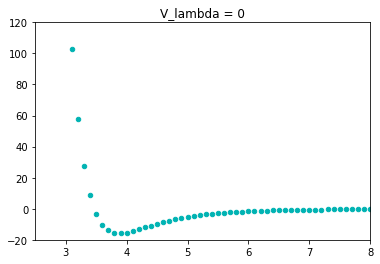

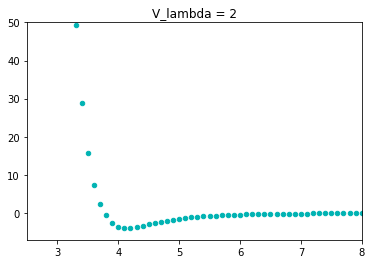

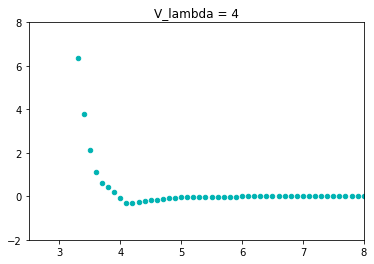

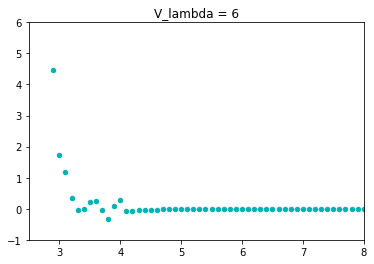

In [5]:
# Plot raw data
# change x and y limits (in plot) as needed for each plot!
x_i, x_f = [-20,-7,-2,-1], [120,50,8,6]
y_i, y_f = 2.5, 8

for i in range(0,lm):
    y_dummy = df_Vnf[str(i*2)] # reads column names (which were originally interegrs) as string
    # Plot the noisy exponential data
    plt.scatter(x_dummy, y_dummy,s=20, color='#00b3b3', label='Data')
    plt.title("V_lambda = %d" %(i*2))
    plt.ylim(x_i[i], x_f[i])
    plt.xlim(y_i, y_f)
    plt.show()

#### In MOLSCAT arrays NPOWER, E and A control curve fitting parameters. (READ HERE):
https://github.com/molscat/molscat

##### The 3 common functions are included that can be edited. 

In [6]:
# Template functions to fit V_lambdas

from scipy.optimize import curve_fit

d,e,f,rmsx2 = np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm)
g,h,l,rmsx3 = np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm)
m,n,rmsx5 = np.zeros(lm),np.zeros(lm),np.zeros(lm)

# A more generalized function will give less error but overfit

def exp_fit_3(x, d,e,f):
    return  d*np.exp(-1*x)+ e*np.exp(-2*x)+ f*np.exp(-3*x)

def fit_12_exp(x, g,h,l):
    return  g*np.exp(-l*x)+ h*np.power(x,-12)

def fit_12_6(x, m,n):
    return  m*np.power(x,-12) + n*np.power(x,-6)


V_lam =  0 	 : 		Error 		 Covarance
exp_fit_3 	 : 	  0.22829246611015414 138976827.39995882
fit_12_exp 	 : 	  0.15145159922069543 9.840184475256984e+18
fit_12_6 	 : 	  0.3237985518231173 24168895.928409763


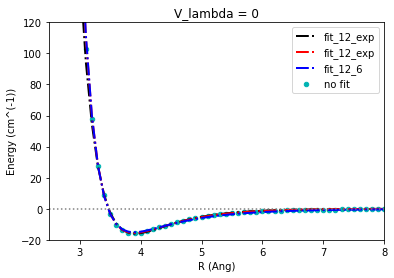

V_lam =  2 	 : 		Error 		 Covarance
exp_fit_3 	 : 	  0.3149295831910745 93216798.58397247
fit_12_exp 	 : 	  0.22060647113997042 3.5836623679326477e+21
fit_12_6 	 : 	  0.41958040423818643 16648986.218482744


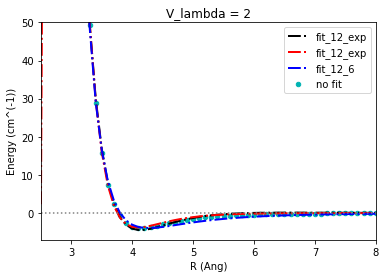

V_lam =  4 	 : 		Error 		 Covarance
exp_fit_3 	 : 	  0.14883109401479064 41955570.599254906
fit_12_exp 	 : 	  0.05275712569857684 1.7376686232141249e+19
fit_12_6 	 : 	  0.11468817914104838 7618087.726315987


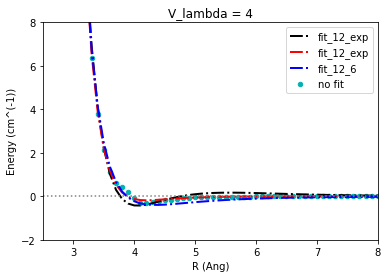

V_lam =  6 	 : 		Error 		 Covarance
exp_fit_3 	 : 	  0.12900166205340446 28155458.452740107
fit_12_exp 	 : 	  0.09243002146046839 2.3794638286931063e+19
fit_12_6 	 : 	  0.12547630352370695 5052023.254694882


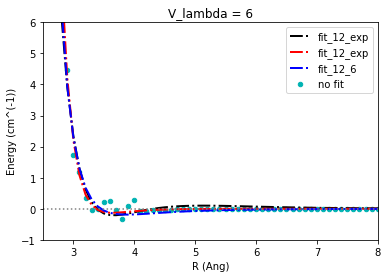

In [20]:
# select inital range for analytical fit (leave high energy points for beter fit)!

# starting point for fitting into function
ini_val = [8,7,5,4] 

# cov and error variables
covx1,covx2,covx3 = np.zeros(lm),np.zeros(lm),np.zeros(lm)
er1,er2,er3 = np.zeros(lm),np.zeros(lm),np.zeros(lm)

# Fitting data into analytic function and plotting for visualization
for ii in range(0,lm):
    y_dummy = df_Vnf[str(ii*sym)]
    
    # fitting with various functions
    
    parsx1, covx1 = curve_fit(f=exp_fit_3, xdata=x_dummy[ini_val[ii]:], ydata=y_dummy[ini_val[ii]:], 
                                  p0=[0,0,1000])
    d[ii],e[ii],f[ii] = parsx1
    
    parsx2, covx2 = curve_fit(f=fit_12_exp, xdata=x_dummy[ini_val[ii]:], ydata=y_dummy[ini_val[ii]:], 
                            p0=[0,1000,2],bounds=((-np.inf, -np.inf, 0.5), (np.inf, np.inf, 5)))
    g[ii],h[ii],l[ii] = parsx2
    
    parsx3, covx3 = curve_fit(f=fit_12_6, xdata=x_dummy[ini_val[ii]:], ydata=y_dummy[ini_val[ii]:], 
                                  p0=[0,1000])
    m[ii],n[ii] = parsx3
    
    # calculate error for each fir
    er1[ii] = np.sqrt(np.average(np.power((exp_fit_3 (x_dummy[ini_val[ii]:], *parsx1) - y_dummy[ini_val[ii]:]),2)))
    er2[ii] = np.sqrt(np.average(np.power((fit_12_exp (x_dummy[ini_val[ii]:], *parsx2) - y_dummy[ini_val[ii]:]),2)))
    er3[ii] = np.sqrt(np.average(np.power((fit_12_6(x_dummy[ini_val[ii]:], *parsx3) - y_dummy[ini_val[ii]:]),2)))
    
    # print error and covariance
    print('V_lam = ', ii*sym, '\t : \t\tError \t\t Covarance')
    print('exp_fit_3 \t : \t ', er1[ii], np.linalg.cond(covx1))
    print('fit_12_exp \t : \t ', er2[ii], np.linalg.cond(covx2))
    print('fit_12_6 \t : \t ', er3[ii], np.linalg.cond(covx3))
    
    # plot original curve
    plt.scatter(x_dummy, y_dummy,s=20, color='#00b3b3',label = 'no fit')
    
    # plot fitted curves
    plt.plot(x_dummy,  exp_fit_3(x_dummy, *parsx1), linestyle='-.', linewidth=2, color='black', label = 'fit_12_exp')
    plt.plot(x_dummy,  fit_12_exp(x_dummy, *parsx2), linestyle='-.', linewidth=2, color='red', label = 'fit_12_exp')
    plt.plot(x_dummy, fit_12_6(x_dummy, *parsx3), linestyle='-.', linewidth=2, color='blue', label = 'fit_12_6')
    
    plt.legend(loc="upper right")
    plt.ylabel("Energy (cm^(-1))")
    plt.xlabel("R (Ang)")
    plt.axhline(y=0, color='grey', linestyle=':')
    plt.title("V_lambda = %d" %(ii*sym))
    plt.ylim(x_i[ii], x_f[ii])
    plt.xlim(y_i, y_f)
    plt.show()
        

#### Template for saving each V lambdas as required by molscat!


In [21]:
# Template for EXP-3 function

print('LAMBDA = ',*([i*sym for i in range (lm)]))
print('NTERM  = ', '3,'*lm)
print('NPOWER = ', '0,0,0,'*lm)
print('A      = ')
for j in range (lm):
    print(d[j],',',e[j],',',f[j],',')
print('E      =', '-1,-2,-3,'*10)

LAMBDA =  0 2 4 6
NTERM  =  3,3,3,3,
NPOWER =  0,0,0,0,0,0,0,0,0,0,0,0,
A      = 
-348.8743722006384 , -83949.20142334526 , 3068319.9675202463 ,
189.01892882343208 , -75704.25692432174 , 2905221.5754147274 ,
95.30131350741651 , -15284.365300642776 , 482111.164869272 ,
36.59411392517567 , -3820.5464694103075 , 80866.25299646235 ,
E      = -1,-2,-3,-1,-2,-3,-1,-2,-3,-1,-2,-3,-1,-2,-3,-1,-2,-3,-1,-2,-3,-1,-2,-3,-1,-2,-3,-1,-2,-3,


In [22]:
# Template for EXP and R**-12 Function 

print('LAMBDA = ',*([i*sym for i in range (lm)]))
print('NTERM  = ', '2,'*lm)
print('NPOWER = ', '0,12,'*lm)
print('A      = ')
for j in range (lm):
    print(g[j],',',h[j],',')
print('E      = ')
for j in range (lm):
    print(l[j],',')

LAMBDA =  0 2 4 6
NTERM  =  2,2,2,2,
NPOWER =  0,12,0,12,0,12,0,12,
A      = 
-6469.235133255057 , 154537014.19235426 ,
95720712.86374603 , -339592255.7504787 ,
17061269.267522562 , -17185512.192476466 ,
19779368.030451823 , -2043182.4435008338 ,
E      = 
1.394525631058717 ,
3.8915070829651364 ,
4.190473502064657 ,
4.999999999999753 ,


In [23]:
# Template for LJ (12-6)

print('LAMBDA = ',*([i*sym for i in range (lm)]))
print('NTERM  = ', '2,'*lm)
print('NPOWER = ', '12,6,'*lm)
print('A      = ')
for j in range (lm):
    print(m[j],',',n[j],',')


LAMBDA =  0 2 4 6
NTERM  =  2,2,2,2,
NPOWER =  12,6,12,6,12,6,12,6,
A      = 
181298782.33150506 , -104836.53263073681 ,
142320687.2579218 , -47249.78626230899 ,
18132606.257034905 , -5359.4855660850035 ,
2149832.4721329277 , -1275.2826258973382 ,
